In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *
from src.pipeline.props_pipeline.ppm_pipeline import *
from src.pipeline.props_pipeline.min_pipeline import *
from src.features.feature_engineer.min_features import min_features

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

# pos = pd.read_csv('data/raw/player_positions/player_positions.csv')
# s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
s25['STARTING'] = s25['START_POSITION'].notna().astype(int)
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
s26['STARTING'] = s26['START_POSITION'].notna().astype(int)
s26.tail()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,pos,age,STARTING
132,2025-26,1630536,Sharife Cooper,Sharife,1610612764,WAS,Washington Wizards,22501087,2026-03-29T00:00:00,WAS @ POR,L,19.000000,4,9,0.444,0,1,0.000,2,2,1.000,0,1,1,2,2,0,0,0,1,2,10,-11,12.2,0,0,13.0,1,19:00,1,90.4,90.0,90.0,121.8,120.5,120.5,-31.4,-30.5,-30.5,0.250,1.0,14.3,0.000,0.056,0.027,14.3,14.4,0.444,0.506,0.279,0.291,99.08,99.79,83.16,99.79,0.077,40,4.0,9.0,32,87,0.368,5,22,0.227,19,22,0.864,9,30,39,16,16.0,7,2,10,28,24,88,-35.0,84.9,85.4,119.3,119.4,-34.4,-34.0,0.500,1.00,12.1,0.232,0.696,0.441,0.155,0.397,0.455,103.4,103.0,85.83,103,0.280,1610612757,POR,Portland Trail Blazers,44,86,0.512,12,36,0.333,23,32,0.719,11,38,49,24,14.0,8,10,2,24,28,123,35.0,119.3,119.4,84.9,85.4,34.4,34.0,0.545,1.71,17.0,0.304,0.768,0.559,0.136,0.581,0.615,103.4,103.0,85.83,103,0.720,NaN,PG,24.0,0
131,2025-26,1630264,Anthony Gill,Anthony,1610612764,WAS,Washington Wizards,22501087,2026-03-29T00:00:00,WAS @ POR,L,30.600000,4,7,0.571,0,1,0.000,0,0,0.000,0,3,3,0,2,1,0,1,4,1,8,-34,12.6,0,0,13.0,1,30:36,1,77.0,76.5,76.5,130.2,128.4,128.4,-53.2,-51.9,-51.9,0.000,0.0,0.0,0.000,0.103,0.049,22.2,22.2,0.571,0.571,0.122,0.126,104.75,105.88,88.24,105.88,0.026,68,4.0,7.0,32,87,0.368,5,22,0.227,19,22,0.864,9,30,39,16,16.0,7,2,10,28,24,88,-35.0,84.9,85.4,119.3,119.4,-34.4,-34.0,0.500,1.00,12.1,0.232,0.696,0.441,0.155,0.397,0.455,103.4,103.0,85.83,103,0.280,1610612757,POR,Portland Trail Blazers,44,86,0.512,12,36,0.333,23,32,0.719,11,38,49,24,14.0,8,10,2,24,28,123,35.0,119.3,119.4,84.9,85.4,34.4,34.0,0.545,1.71,17.0,0.304,0.768,0.559,0.136,0.581,0.615,103.4,103.0,85.83,103,0.720,NaN,PF,33.0,0
130,2025-26,1629021,Moritz Wagner,Moritz,1610612753,ORL,Orlando Magic,22501086,2026-03-29T00:00:00,ORL @ TOR,L,12.000000,3,6,0.500,1,2,0.500,0,0,0.000,0,4,4,1,0,0,0,1,0,1,7,-7,13.3,0,0,13.0,1,12:00,1,73.1,70.4,70.4,100.5,100.0,100.0,-27.4,-29.6,-29.6,0.200,0.0,14.3,0.000,0.333,0.160,0.0,0.0,0.583,0.583,0.222,0.231,103.76,106.00,88.33,106.00,0.162,27,3.0,6.0,31,82,0.378,9,38,0.237,16,19,0.842,9,27,36,20,28.0,4,1,3,20,18,87,-52.0,79.6,83.7,129.1,132.4,-49.5,-48.7,0.645,0.71,14.4,0.283,0.705,0.474,0.269,0.433,0.481,108.5,104.5,87.08,104,0.195,1610612761,TOR,Toronto Raptors,54,94,0.574,13,29,0.448,18,22,0.818,7,37,44,41,11.0,20,3,1,18,20,139,52.0,129.1,132.4,79.6,83.7,49.5,48.7,0.759,3.73,25.8,0.295,0.717,0.526,0.105,0.644,0.670,108.5,104.5,87.08,105,0.805,NaN,C,28.0,0
141,2025-26,1631218,Tr

In [ ]:
res = []
for df in [s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

    # Derived features
    df['MIN'] = df['MIN'].round(2)
    df = min_features(df)
    df['TEAM_PTS_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_PTS_RANK_BY_POS_L5'] = (
    df.groupby(['TEAM_ID', 'GAME_DATE', 'pos'])['PTS_roll5']
    .rank(ascending=False, method='dense'))
    df['TEAM_POSS_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['POSS_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_POSS_RANK_BY_POS_L5'] = (
    df.groupby(['TEAM_ID', 'GAME_DATE', 'pos'])['POSS_roll5']
    .rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_BY_POS_L5'] = (
    df.groupby(['TEAM_ID', 'GAME_DATE', 'pos'])['MIN_roll5']
    .rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_BY_POS_L10'] = (
    df.groupby(['TEAM_ID', 'GAME_DATE', 'pos'])['USG_PCT_roll10']
    .rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_PIE_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PIE_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_BY_POS_L5'] = (df.groupby(['TEAM_ID', 'GAME_DATE', 'pos'])['USG_PCT_roll5'].rank(ascending=False, method='dense'))
    df['USG_EWM_L12'] = (df.groupby('PLAYER_ID')['USG_PCT'].transform(lambda x: x.shift(1).ewm(span=12, adjust=False).mean()))
    df['USG_EWM_L5'] = (df.groupby('PLAYER_ID')['USG_PCT'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['MIN_EWM_L12'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=12, adjust=False).mean()))
    df['MIN_EWM_L5'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['MIN_EWM_L3'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean()))
    df['MEDIAN_MIN_L10'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(10).median()))
    df['STARTER_X_MIN_AVG'] = df['STARTING'] * df['MIN_season_avg']
    df['AGE_X_B2B'] = df['age'] * df['IS_B2B']
    df['HOME_X_MIN_AVG'] = df['IS_HOME'] * df['MIN_season_avg']
    df['EXPECTED_MARGIN'] = (df['TEAM_NET_RATING_roll5'] - df['OPP_NET_RATING_roll5']).abs()
    df['MIN_MAX_L5'] = df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(5).max())
    df['MIN_MIN_L5'] = df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(5).min())
    df['HIGH_MIN_PLAYER'] = (df['MIN_roll10'] > 30).astype(int)
    df['HIGH_MIN_TIER'] = np.nan
    mask = df['MIN_EWM_L12'].notna()
    df.loc[mask, 'HIGH_MIN_TIER'] = pd.cut(
        df.loc[mask, 'MIN_EWM_L12'],
        bins=[0, 20, 25, 30, 34, 100],
        labels=[0, 1, 2, 3, 4],
        include_lowest=True,
    ).astype(int)
    df["GP"] = df.groupby("PLAYER_ID").cumcount()
    le = LabelEncoder()
    df['POSITION_ENC'] = le.fit_transform(df['pos'])
    df['PLAYER_ENC'] = le.fit_transform(df['PLAYER_NAME'])
    df['ROLE_LOCK'] = (
    df['STARTER_ROLL10_PCT'] * df['MIN_std10'].apply(lambda x: 1/x))  # high start% + low variance = locked in role = safest bet
    df['ROLE_SHOCK'] = (
    df['MIN_EWM_L5'] - df['MIN_EWM_L12']          # short vs long term gap
    ) / df['MIN_EWM_L12']                            # normalized as % change
    df['PM_PER_MIN']    = df['PLUS_MINUS_lag1'] / df['MIN_lag1'].replace(0, np.nan)
    df['PM_PER_MIN_R10']= df['PM_PER_MIN'].transform(lambda x: x.shift(1).rolling(10).mean())
    # df["MIN_ABOVE_35_L10"] = (
    # (df["MIN"] >= 35)
    # .groupby(df["PLAYER_ID"])
    # .shift(1)                       # exclude current game to avoid leakage
    # .rolling(10, min_periods=1)
    # .sum()
    # .reset_index(level=0, drop=True))
    
    player_avgs = df[df['MIN'] > 0].groupby('PLAYER_ID')['MIN'].apply(
    lambda x: (x >= 15).mean())
    eligible = player_avgs[player_avgs >= 0.50].index
    df = df[df['PLAYER_ID'].isin(eligible)]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df[df['PLAYER_NAME'] == 'LeBron James']

(41107, 318)


,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,pos,age,STARTING,MIN_roll3,PTS_roll3,REB_roll3,AST_PCT_roll3,OREB_PCT_roll3,DREB_PCT_roll3,TM_TOV_PCT_roll3,PLUS_MINUS_roll3,PF_roll3,POSS_roll3,PIE_roll3,USG_PCT_roll3,TS_PCT_roll3,NET_RATING_roll3,OFF_RATING_roll3,DEF_RATING_roll3,MIN_roll5,PTS_roll5,REB_roll5,AST_PCT_roll5,OREB_PCT_roll5,DREB_PCT_roll5,TM_TOV_PCT_roll5,PLUS_MINUS_roll5,PF_roll5,POSS_roll5,PIE_roll5,USG_PCT_roll5,TS_PCT_roll5,NET_RATING_roll5,OFF_RATING_roll5,DEF_RATING_roll5,MIN_roll10,PTS_roll10,REB_roll10,AST_PCT_roll10,OREB_PCT_roll10,DREB_PCT_roll10,TM_TOV_PCT_roll10,PLUS_MINUS_roll10,PF_roll10,POSS_roll10,PIE_roll10,USG_PCT_roll10,TS_PCT_roll10,NET_RATING_roll10,OFF_RATING_roll10,DEF_RATING_roll10,MIN_lag1,PTS_lag1,PLUS_MINUS_lag1,PIE_lag1,STARTING_lag1,POSS_lag1,USG_PCT_lag1,AST_lag1,REB_lag1,STL_lag1,BLK_lag1,MIN_lag2,PTS_lag2,PLUS_MINUS_lag2,PIE_lag2,STARTING_lag2,POSS_lag2,USG_PCT_lag2,AST_lag2,REB_lag2,STL_lag2,BLK_lag2,MIN_lag3,PTS_lag3,PLUS_MINUS_lag3,PIE_lag3,STARTING_lag3,POSS_lag3,USG_PCT_lag3,AST_lag3,REB_lag3,STL_lag3,BLK_lag3,STARTER_ROLL10_PCT,MIN_season_avg,PTS_season_avg,REB_season_avg,AST_season_avg,STL_season_avg,BLK_season_avg,TOV_season_avg,FGM_season_avg,FGA_season_avg,FG_PCT_season_avg,FG3M_season_avg,FG3A_season_avg,FG3_PCT_season_avg,OREB_season_avg,DREB_season_avg,PLUS_MINUS_season_avg,PF_season_avg,POSS_season_avg,PIE_season_avg,USG_PCT_season_avg,TS_PCT_season_avg,NET_RATING_season_avg,TEAM_PACE_roll5,TEAM_PTS_roll5,TEAM_NET_RATING_roll5,MIN_share_proxy,PTS_share_proxy,TEAM_POSS_roll5,TEAM_POSS_share,DAYS_REST,IS_B2B,IS_HOME,GAME_NUMBER,MIN_std10,MIN_std5,MIN_std20,OPP_DEF_RATING_roll5,OPP_DEF_RATING_roll10,OPP_PACE_roll5,OPP_PACE_roll10,OPP_POSS_roll5,OPP_POSS_roll10,OPP_NET_RATING_roll5,OPP_NET_RATING_roll10,EXPECTED_PACE,PACE_DIFFERENTIAL,PLAYER_IS_TEAM_STAR,STAR_SAT_OUT,rot_group,exp_min,active_pos_min_sum,pos_cap,POS_VACANCY,PLAYER_POS_OPPORTUNITY,TEAM_PTS_RANK_L10,TEAM_PTS_RANK_BY_POS_L10,TEAM_MIN_RANK_L10,TEAM_MIN_RANK_BY_POS_L10,TEAM_MIN_RANK_L5,TEAM_USG_RANK_L10,TEAM_USG_RANK_BY_POS_L10,MIN_ewm10,MIN_ewm5,MIN_ewm3,MEDIAN_MIN_L20,STARTER_X_DAYS_REST,STARTER_X_MIN_AVG,STARTER_X_PLAYER_IS_TEAM_STAR,AGE_X_B2B,MAX_MIN_L10,MIN_MIN_L10,MIN_TREND,EXPECTED_MARGIN,GP,POSITION_ENC,PLAYER_ENC,TEAM_TOTAL_TYPICAL_MIN,VACANT_MINUTES
0,2024-25,2544,LeBron James,LeBron,1610612747,LAL,Los Angeles Lakers,22400062,2024-10-22,LAL vs. MIN,W,34.65,7,16,0.438,1,4,0.250,1,1,

In [ ]:
MIN_FEATURES = [
    # Tier 1 — Core role
    'STARTER_X_MIN_AVG',
    'MIN_EWM_L12',
    'MIN_EWM_L3',
    'STARTING_lag1',
    'STARTER_ROLL10_PCT',
    'ROLE_LOCK',
    'MEDIAN_MIN_L10',
    'MIN_MIN_L5',#new
    'MIN_MAX_L5',#new
    'HIGH_MIN_TIER',#new
    
    # Tier 2 — Team context
    'TEAM_MIN_RANK_L5',
    'TEAM_POSS_RANK_L5',
    'TEAM_PTS_RANK_L5',
    'TEAM_USG_RANK_L5',
    'POSS_roll5',

    # Tier 3 — Situational
    'DAYS_REST',
    'AGE_X_B2B',
    'USG_EWM_L5',
    'PM_PER_MIN_R10',
    'POSITION_ENC',
    'HOME_X_MIN_AVG',
    'MIN_share_proxy',
    'TEAM_POSS_RANK_BY_POS_L5',  # keep ONE by-pos feature
]

In [72]:
# Drop rows with NaN in features or target
min_df = df[MIN_FEATURES + ["MIN", "GAME_DATE"]].dropna()

# -- TIME-BASED SPLIT --
split_date = min_df["GAME_DATE"].quantile(0.75)  # train on first 75% of season
train_mask = min_df["GAME_DATE"] <= split_date
val_mask   = ~train_mask

X_train_min = min_df.loc[train_mask, MIN_FEATURES]
y_train_min = min_df.loc[train_mask, "MIN"]
X_val_min   = min_df.loc[val_mask, MIN_FEATURES]
y_val_min   = min_df.loc[val_mask, "MIN"]

xgb_min = XGBRegressor(
    n_estimators=800,
    learning_rate=0.01,
    max_depth=7,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.9,
    reg_alpha=0.5,
    reg_lambda=1.5,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

xgb_min.fit(
    X_train_min,
    y_train_min,
    eval_set=[(X_val_min, y_val_min)],
    verbose=False,
)

min_preds_val = xgb_min.predict(X_val_min)
min_mae = mean_absolute_error(y_val_min, min_preds_val)
min_rmse = np.sqrt(mean_squared_error(y_val_min, min_preds_val))
min_r2 = r2_score(y_val_min, min_preds_val)

print(f"[Minutes Model] Validation R2: {min_r2:.4f}")
print(f"[Minutes Model] Validation RMSE: {min_rmse:.2f} min")
print(f"[Minutes Model] Validation MAE: {min_mae:.2f} min")

[Minutes Model] Validation R2: 0.5494
[Minutes Model] Validation RMSE: 5.63 min
[Minutes Model] Validation MAE: 4.37 min


In [73]:
importance = pd.Series(xgb_min.feature_importances_, index=MIN_FEATURES)
importance = importance.sort_values(ascending=False)

importance[:50]

STARTER_X_MIN_AVG     0.509868
MIN_ewm10             0.143093
TEAM_MIN_RANK_L5      0.109157
MIN_ewm5              0.052700
STARTING_lag1         0.030960
STARTER_ROLL10_PCT    0.025457
MEDIAN_MIN_L20        0.018098
TEAM_USG_RANK_L10     0.017156
DAYS_REST             0.015369
MAX_MIN_L10           0.015222
TEAM_POSS_roll5       0.013731
AGE_X_B2B             0.013692
EXPECTED_MARGIN       0.013129
POSITION_ENC          0.012171
IS_HOME               0.010197
dtype: float32

In [60]:
sub = df[["MIN", "MIN_ewm10"]].dropna()
baseline_mae = mean_absolute_error(sub["MIN"], sub["MIN_ewm10"])
print(f"Naive baseline MAE: {baseline_mae:.2f}")
print(f"Model MAE: {round(min_mae, 2)}")
print(f"Lift: {baseline_mae - min_mae:.2f} min")

Naive baseline MAE: 4.78
Model MAE: 4.41
Lift: 0.37 min


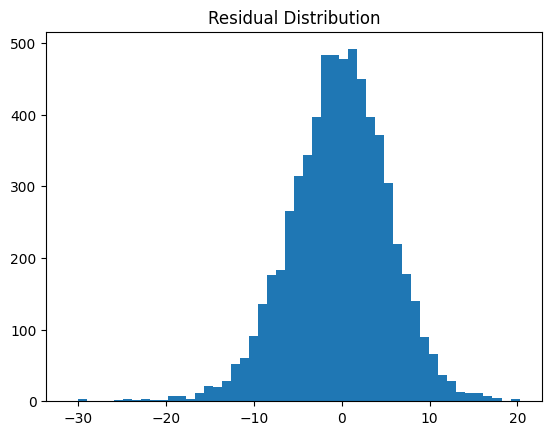

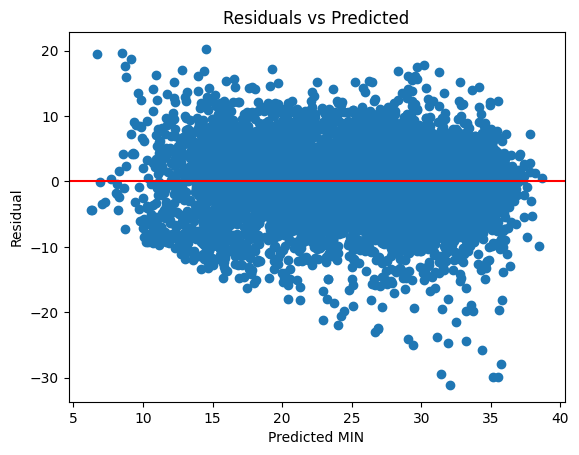

In [61]:
import matplotlib.pyplot as plt


residuals = y_val_min - min_preds_val

# Distribution of errors
plt.hist(residuals, bins=50)
plt.title('Residual Distribution')
plt.show()

# Are errors random or structured?
plt.scatter(min_preds_val, residuals)
plt.axhline(0, color='red')
plt.xlabel('Predicted MIN')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted')
plt.show()

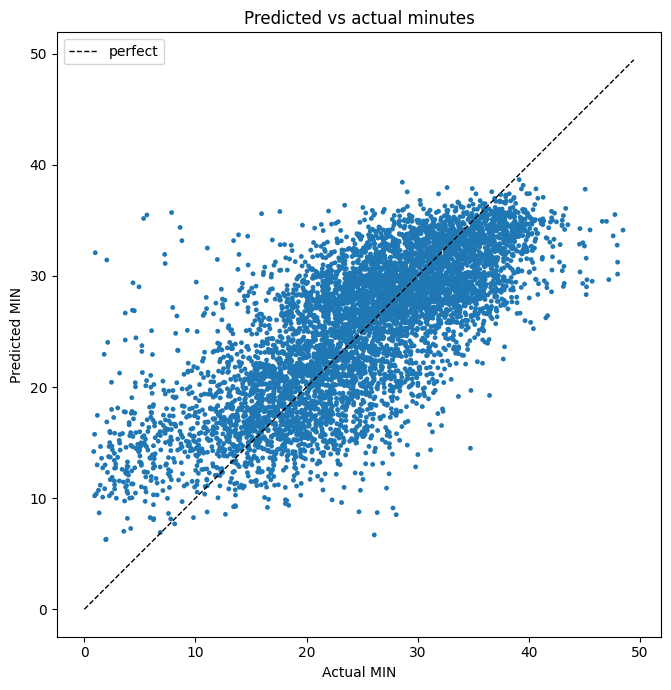

Pred quantiles: 0.50    26.691832
0.90    33.391964
0.95    34.500563
0.99    35.994531
dtype: float64
Actual quantiles: 0.50    25.7700
0.90    35.5800
0.95    37.6000
0.99    40.8212
Name: MIN, dtype: float64


In [62]:
y_true = y_val_min
y_pred = min_preds_val

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_true, y_pred, s=12, edgecolors="none")
lims = [0, max(y_true.max(), y_pred.max()) * 1.02]
ax.plot(lims, lims, "k--", lw=1, label="perfect")
ax.set_xlabel("Actual MIN")
ax.set_ylabel("Predicted MIN")
ax.set_title("Predicted vs actual minutes")
ax.set_aspect("equal", adjustable="box")
ax.legend()
plt.tight_layout()
plt.show()

print("Pred quantiles:", pd.Series(y_pred).quantile([0.5, 0.9, 0.95, 0.99]))
print("Actual quantiles:", pd.Series(y_true).quantile([0.5, 0.9, 0.95, 0.99]))

In [63]:
# Use quantile regression to get a range instead of a single number
from sklearn.ensemble import GradientBoostingRegressor

lower = GradientBoostingRegressor(loss='quantile', alpha=0.1)
upper = GradientBoostingRegressor(loss='quantile', alpha=0.9)
mid   = GradientBoostingRegressor(loss='quantile', alpha=0.5)

lower.fit(X_train_min, y_train_min)
upper.fit(X_train_min, y_train_min)
mid.fit(X_train_min, y_train_min)

pred_low  = lower.predict(X_val_min)
pred_high = upper.predict(X_val_min)
pred_mid  = mid.predict(X_val_min)

# Coverage — what % of actuals fall within the interval?
coverage = ((y_val_min >= pred_low) & (y_val_min <= pred_high)).mean()
print(f"Coverage: {coverage:.2%}")  # want this close to 80%

Coverage: 78.57%


In [41]:
results = pd.DataFrame({'actual': y_val_min.values, 'predicted': min_preds_val})

# Bin predictions and compare to actuals
results['bucket'] = pd.cut(results['predicted'], bins=10)
calibration = results.groupby('bucket').agg(
    mean_predicted=('predicted', 'mean'),
    mean_actual=('actual', 'mean'),
    count=('actual', 'count')
)
print(calibration)

                  mean_predicted  mean_actual  count
bucket                                              
(3.45, 7.073]           5.318351     5.197143      7
(7.073, 10.661]         9.647508     9.931370     73
(10.661, 14.248]       12.805799    12.572915    295
(14.248, 17.836]       16.042227    16.501159    647
(17.836, 21.423]       19.707842    19.742096    792
(21.423, 25.011]       23.221155    23.026116    981
(25.011, 28.598]       27.051123    26.883326   1293
(28.598, 32.185]       30.215551    30.059637   1379
(32.185, 35.773]       33.737629    33.287158    767
(35.773, 39.36]        36.921963    36.182788    165


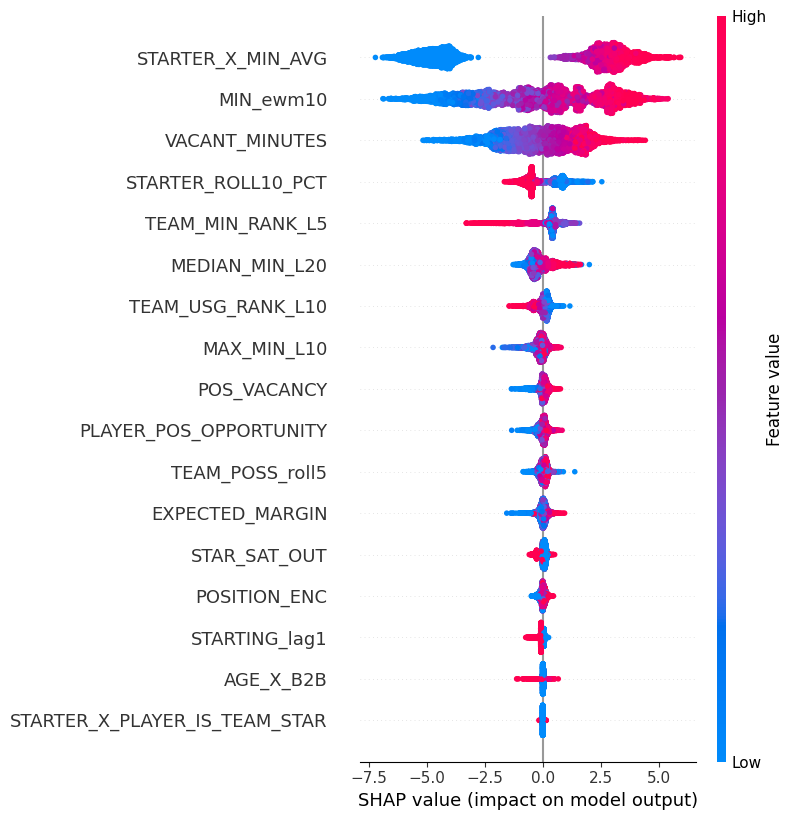

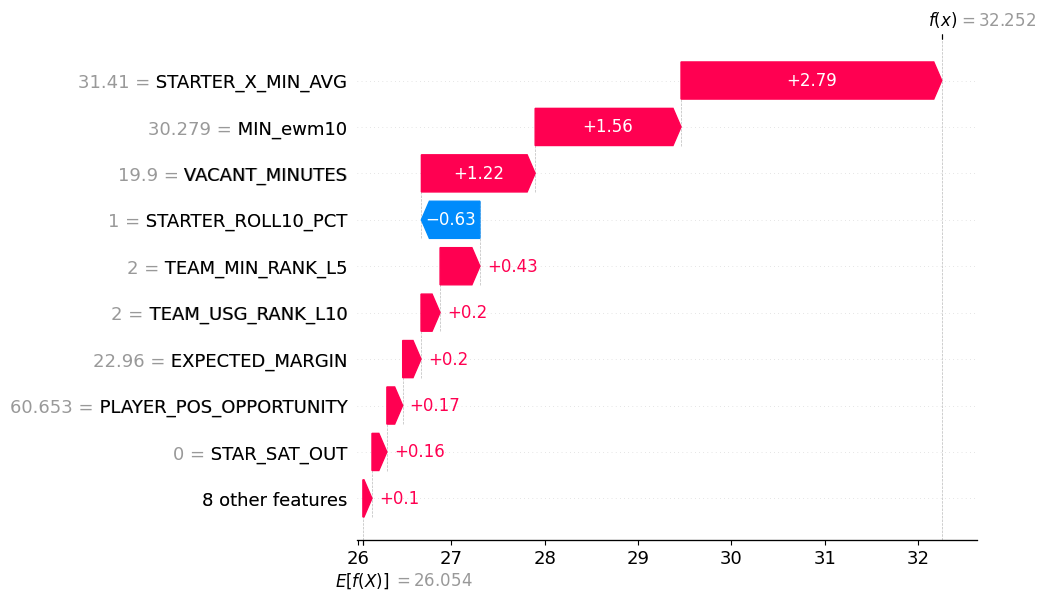

In [42]:
import shap

explainer   = shap.TreeExplainer(xgb_min)
shap_values = explainer(X_val_min) 

# Global feature importance
shap.summary_plot(shap_values, X_val_min, feature_names=MIN_FEATURES)

# Single prediction waterfall
shap.plots.waterfall(shap_values[1154])

In [13]:
# from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit


# # Drop rows with NaN in features/target and keep GAME_DATE for time split
# min_df = df[MIN_FEATURES + ["MIN", "GAME_DATE"]].dropna()

# # -- TIME-BASED SPLIT (same style as your new notebook) --
# split_date = min_df["GAME_DATE"].quantile(0.75)  # train on first 75% of season
# train_mask = min_df["GAME_DATE"] <= split_date
# val_mask   = ~train_mask

# X_train_min = min_df.loc[train_mask, MIN_FEATURES]
# y_train_min = min_df.loc[train_mask, "MIN"]
# X_val_min   = min_df.loc[val_mask, MIN_FEATURES]
# y_val_min   = min_df.loc[val_mask, "MIN"]

# param_grid = {
#     "n_estimators": [200, 400, 600, 800],
#     "learning_rate": [0.01, 0.03, 0.05, 0.1],
#     "max_depth": [3, 4, 5, 6, 8],
#     "min_child_weight": [1, 3, 5],
#     "subsample": [0.7, 0.8, 0.9, 1.0],
#     "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
#     "reg_alpha": [0.0, 0.1, 1.0],
#     "reg_lambda": [1.0, 2.0, 5.0],
# }

# xgb_min = XGBRegressor(
#     objective="reg:squarederror",
#     random_state=42,
#     n_jobs=-1
# )

# # Time-aware CV for hyperparameter search on training period only
# tscv = TimeSeriesSplit(n_splits=5)

# search_min = RandomizedSearchCV(
#     estimator=xgb_min,
#     param_distributions=param_grid,
#     n_iter=100,
#     scoring="neg_mean_squared_error",
#     cv=tscv,
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )

# search_min.fit(X_train_min, y_train_min)

# print("Best params:", search_min.best_params_)

# min_preds_val = search_min.best_estimator_.predict(X_val_min)

# min_r2 = r2_score(y_val_min, min_preds_val)
# min_rmse = np.sqrt(mean_squared_error(y_val_min, min_preds_val))
# min_mae = mean_absolute_error(y_val_min, min_preds_val)

# print(f"[Minutes Model] Validation R2: {min_r2:.4f}")
# print(f"[Minutes Model] Validation RMSE: {min_rmse:.2f} min")
# print(f"[Minutes Model] Validation MAE: {min_mae:.2f} min")

## Model Analysis

In [61]:
target_date = pd.Timestamp("2026-03-26")
hist = df[df["GAME_DATE"] < target_date].copy()

lines_dfs = pd.read_csv('/Users/alexgonzalez/Documents/NBA-Prop-Predictor/data/raw/player_lines/NBA_DFS_20260326_151151.csv')
lines_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_points')]
names = lines_dfs['NAME'].unique()

In [62]:
records = []

for name in names:
    try:
        if name in nameDict:
            name = nameDict[name]
        features = min_pipeline(df, name)
        min_arr = np.asarray(features, dtype=float).reshape(1, -1)
        predicted = float(xgb_min.predict(min_arr)[0])
        records.append({"PLAYER_NAME": name, "PRED_MIN": predicted})
    except Exception as e:
        records.append({"PLAYER_NAME": name, "PRED_MIN": np.nan})
        print(f"[SKIP] {name}: {e}")

preds_df = pd.DataFrame(records)
preds_df.head()

[SKIP] Mohamed Diawara: Feature shape mismatch, expected: 17, got 1
[SKIP] Herb Jones: Feature shape mismatch, expected: 17, got 1
[SKIP] Wendell Carter Jr: Feature shape mismatch, expected: 17, got 1
[SKIP] Jamal Cain: Feature shape mismatch, expected: 17, got 1
[SKIP] Devin Carter: Feature shape mismatch, expected: 17, got 1


,PLAYER_NAME,PRED_MIN
0,Karl-Anthony Towns,29.487827
1,Jordan Clarkson,20.077480
2,Mitchell Robinson,19.052340
3,Kon Knueppel,29.690300
4,Grant Williams,15.883443


In [67]:
actuals = df[df["GAME_DATE"] == target_date][["PLAYER_NAME", "MIN"]].copy()

analysis = preds_df.merge(actuals, on="PLAYER_NAME", how="left")
analysis.rename(columns={"MIN": "ACTUAL_MIN"}, inplace=True)
analysis["ERROR"]     = analysis["PRED_MIN"] - analysis["ACTUAL_MIN"]
analysis["ABS_ERROR"] = analysis["ERROR"].abs()
analysis["PCT_ERROR"] = (analysis["ABS_ERROR"] / analysis["ACTUAL_MIN"].replace(0, np.nan)) * 100
analysis.sort_values("ABS_ERROR", ascending=False).head()

,PLAYER_NAME,PRED_MIN,ACTUAL_MIN,ERROR,ABS_ERROR,PCT_ERROR
11,Yves Missi,27.100466,16.02,11.080466,11.080466,69.166453
17,DeMar DeRozan,30.871824,38.48,-7.608176,7.608176,19.771766
0,Karl-Anthony Towns,29.487827,21.97,7.517827,7.517827,34.218604
3,Kon Knueppel,29.690300,36.94,-7.249700,7.249700,19.625609
2,Mitchell Robinson,19.052340,26.16,-7.107660,7.107660,27.169956


In [68]:
print(f"\n{'='*55}")
print(f"  Minutes Model Audit — {target_date.date()}")
print(f"{'='*55}")
print(f"  Players predicted : {preds_df['PRED_MIN'].notna().sum()} / {len(names)}")
print(f"  Players w/ actuals: {analysis['ACTUAL_MIN'].notna().sum()}")
print(f"  MAE               : {analysis['ABS_ERROR'].mean():.2f} min")
print(f"  RMSE              : {np.sqrt((analysis['ERROR']**2).mean()):.2f} min")
print(f"  Median Abs Error  : {analysis['ABS_ERROR'].median():.2f} min")


  Minutes Model Audit — 2026-03-26
  Players predicted : 30 / 35
  Players w/ actuals: 19
  MAE               : 3.54 min
  RMSE              : 4.71 min
  Median Abs Error  : 2.36 min


In [69]:
MISS_THRESHOLD = 10  # minutes

misses = (
    analysis
    .dropna(subset=["ACTUAL_MIN"])
    .query("ABS_ERROR >= @MISS_THRESHOLD")
    .sort_values("ABS_ERROR", ascending=False)
)

print(f"\n  Players missed by ≥{MISS_THRESHOLD} min: {len(misses)}")
print(f"\n{'─'*55}")
print(f"  {'PLAYER':<25} {'PRED':>6} {'ACTUAL':>7} {'ERROR':>7} {'%ERR':>7}")
print(f"{'─'*55}")

for _, row in misses.iterrows():
    direction = "↑" if row["ERROR"] > 0 else "↓"
    print(
        f"  {row['PLAYER_NAME']:<25} "
        f"{row['PRED_MIN']:>6.1f} "
        f"{row['ACTUAL_MIN']:>7.1f} "
        f"{direction}{row['ABS_ERROR']:>6.1f} "
        f"{row['PCT_ERROR']:>6.1f}%"
    )


  Players missed by ≥10 min: 1

───────────────────────────────────────────────────────
  PLAYER                      PRED  ACTUAL   ERROR    %ERR
───────────────────────────────────────────────────────
  Yves Missi                  27.1    16.0 ↑  11.1   69.2%


In [70]:
full_view = (
    analysis
    .dropna(subset=["ACTUAL_MIN"])
    .sort_values("ABS_ERROR", ascending=False)
    [["PLAYER_NAME", "PRED_MIN", "ACTUAL_MIN", "ERROR", "ABS_ERROR", "PCT_ERROR"]]
    .round(2)
).head(20)

print(f"\n{'─'*55}")
print("  Full Results (sorted by abs error):")
print(full_view.to_string(index=False))


───────────────────────────────────────────────────────
  Full Results (sorted by abs error):
       PLAYER_NAME  PRED_MIN  ACTUAL_MIN  ERROR  ABS_ERROR  PCT_ERROR
        Yves Missi     27.10       16.02  11.08      11.08      69.17
     DeMar DeRozan     30.87       38.48  -7.61       7.61      19.77
Karl-Anthony Towns     29.49       21.97   7.52       7.52      34.22
      Kon Knueppel     29.69       36.94  -7.25       7.25      19.63
 Mitchell Robinson     19.05       26.16  -7.11       7.11      27.17
    Maxime Raynaud     32.49       38.58  -6.09       6.09      15.78
        Sion James     17.66       14.46   3.20       3.20      22.10
      Goga Bitadze     15.70       12.62   3.08       3.08      24.39
  Precious Achiuwa     31.38       33.75  -2.37       2.37       7.03
  Tristan da Silva     29.91       32.27  -2.36       2.36       7.31
   Jordan Clarkson     20.08       18.07   2.01       2.01      11.11
        Saddiq Bey     32.58       30.75   1.83       1.83       

In [71]:
positions = (
    df.sort_values("GAME_DATE")
    .groupby("PLAYER_NAME")["Position"]
    .last()
    .reset_index()
)

analysis_pos = analysis.merge(positions, on="PLAYER_NAME", how="left").dropna(subset=["ACTUAL_MIN"])

pos_order = ["PG", "SG", "SF", "PF", "C"]

pos_summary = (
    analysis_pos
    .groupby("Position")
    .agg(
        N           = ("PLAYER_NAME", "count"),
        MAE         = ("ABS_ERROR",   "mean"),
        RMSE        = ("ERROR",       lambda x: np.sqrt((x**2).mean())),
        MEDIAN_ERR  = ("ABS_ERROR",   "median"),
        AVG_PRED    = ("PRED_MIN",    "mean"),
        AVG_ACTUAL  = ("ACTUAL_MIN",  "mean"),
        OVER_COUNT  = ("ERROR",       lambda x: (x > 0).sum()),
        UNDER_COUNT = ("ERROR",       lambda x: (x < 0).sum()),
    )
    .reindex(pos_order)
    .dropna(how="all")
    .round(2)
)

print(f"\n{'='*65}")
print(f"  Minutes Model Audit — By Position")
print(f"{'='*65}")
print(f"  {'POS':<6} {'N':>4} {'MAE':>6} {'RMSE':>6} {'MED':>6} {'AVG_PRED':>9} {'AVG_ACT':>8} {'OVER':>5} {'UNDER':>6}")
print(f"{'─'*65}")

for pos, row in pos_summary.iterrows():
    print(
        f"  {pos:<6} {int(row['N']):>4} "
        f"{row['MAE']:>6.2f} {row['RMSE']:>6.2f} {row['MEDIAN_ERR']:>6.2f} "
        f"{row['AVG_PRED']:>9.1f} {row['AVG_ACTUAL']:>8.1f} "
        f"{int(row['OVER_COUNT']):>5} {int(row['UNDER_COUNT']):>6}"
    )

# Biggest miss per position
print(f"\n  Worst miss per position:")
print(f"{'─'*65}")

for pos in pos_order:
    subset = analysis_pos[analysis_pos["Position"] == pos].dropna(subset=["ABS_ERROR"])
    if subset.empty:
        continue
    worst = subset.loc[subset["ABS_ERROR"].idxmax()]
    direction = "↑" if worst["ERROR"] > 0 else "↓"
    print(
        f"  {pos:<5} {worst['PLAYER_NAME']:<25} "
        f"pred={worst['PRED_MIN']:.1f}  actual={worst['ACTUAL_MIN']:.1f}  "
        f"{direction}{worst['ABS_ERROR']:.1f} min"
    )


  Minutes Model Audit — By Position
  POS       N    MAE   RMSE    MED  AVG_PRED  AVG_ACT  OVER  UNDER
─────────────────────────────────────────────────────────────────
  PG        1   1.45   1.45   1.45      31.8     33.3     0      1
  SG        5   2.60   3.66   2.01      25.0     25.5     3      2
  SF        1   7.61   7.61   7.61      30.9     38.5     0      1
  PF        6   2.65   3.48   2.10      28.5     27.4     4      2
  C         6   4.87   6.08   4.58      22.1     22.0     3      3

  Worst miss per position:
─────────────────────────────────────────────────────────────────
  PG    Daniss Jenkins            pred=31.8  actual=33.3  ↓1.4 min
  SG    Kon Knueppel              pred=29.7  actual=36.9  ↓7.2 min
  SF    DeMar DeRozan             pred=30.9  actual=38.5  ↓7.6 min
  PF    Karl-Anthony Towns        pred=29.5  actual=22.0  ↑7.5 min
  C     Yves Missi                pred=27.1  actual=16.0  ↑11.1 min


In [72]:
# ── 10. Situational Error Breakdown (B2B, Home, Rest Days) ────────────────

# Pull situational columns from df for target_date
situational_cols = ["PLAYER_NAME", "IS_B2B", "IS_HOME", "DAYS_REST"]
situational = df[df["GAME_DATE"] == target_date][situational_cols].copy()

analysis_sit = analysis.merge(situational, on="PLAYER_NAME", how="left").dropna(subset=["ACTUAL_MIN"])

def situation_breakdown(df, group_col, label):
    summary = (
        df.groupby(group_col)
        .agg(
            N           = ("PLAYER_NAME", "count"),
            MAE         = ("ABS_ERROR",   "mean"),
            RMSE        = ("ERROR",       lambda x: np.sqrt((x**2).mean())),
            AVG_ERROR   = ("ERROR",       "mean"),   # signed — catches directional bias
            AVG_PRED    = ("PRED_MIN",    "mean"),
            AVG_ACTUAL  = ("ACTUAL_MIN",  "mean"),
            OVER_COUNT  = ("ERROR",       lambda x: (x > 0).sum()),
            UNDER_COUNT = ("ERROR",       lambda x: (x < 0).sum()),
        )
        .round(2)
    )

    print(f"\n{'='*70}")
    print(f"  {label}")
    print(f"{'='*70}")
    print(f"  {'GROUP':<12} {'N':>4} {'MAE':>6} {'RMSE':>6} {'AVG_ERR':>8} {'AVG_PRED':>9} {'AVG_ACT':>8} {'OVER':>5} {'UNDER':>6}")
    print(f"{'─'*70}")

    for group, row in summary.iterrows():
        bias = "↑ over" if row["AVG_ERROR"] > 0 else "↓ under"
        print(
            f"  {str(group):<12} {int(row['N']):>4} "
            f"{row['MAE']:>6.2f} {row['RMSE']:>6.2f} "
            f"{row['AVG_ERROR']:>+8.2f} "
            f"{row['AVG_PRED']:>9.1f} {row['AVG_ACTUAL']:>8.1f} "
            f"{int(row['OVER_COUNT']):>5} {int(row['UNDER_COUNT']):>6}  {bias}"
        )

# ── B2B ───────────────────────────────────────────────────────────────────
situation_breakdown(analysis_sit, "IS_B2B", "Back-to-Back (IS_B2B)")

# ── Home / Away ───────────────────────────────────────────────────────────
situation_breakdown(analysis_sit, "IS_HOME", "Home vs Away (IS_HOME)")

# ── Rest Days ─────────────────────────────────────────────────────────────
# Cap rest days at 4+ to avoid tiny sample sizes for long rest outliers
analysis_sit["DAYS_REST_CAPPED"] = analysis_sit["DAYS_REST"].clip(upper=4).map(
    lambda x: f"{int(x)}+" if x == 4 else str(int(x))
)
situation_breakdown(analysis_sit, "DAYS_REST", "Rest Days (DAYS_REST)")


  Back-to-Back (IS_B2B)
  GROUP           N    MAE   RMSE  AVG_ERR  AVG_PRED  AVG_ACT  OVER  UNDER
──────────────────────────────────────────────────────────────────────
  0.0            17   3.84   4.97    -0.15      25.4     25.5    10      7  ↓ under
  1.0             2   0.97   1.08    -0.97      30.1     31.1     0      2  ↓ under

  Home vs Away (IS_HOME)
  GROUP           N    MAE   RMSE  AVG_ERR  AVG_PRED  AVG_ACT  OVER  UNDER
──────────────────────────────────────────────────────────────────────
  0.0            11   4.35   5.56    -0.08      27.6     27.7     6      5  ↓ under
  1.0             8   2.43   3.19    -0.46      23.4     23.9     4      4  ↓ under

  Rest Days (DAYS_REST)
  GROUP           N    MAE   RMSE  AVG_ERR  AVG_PRED  AVG_ACT  OVER  UNDER
──────────────────────────────────────────────────────────────────────
  1.0             2   0.97   1.08    -0.97      30.1     31.1     0      2  ↓ under
  2.0            16   3.93   5.08    -0.02      25.0     25.0    1

In [73]:
# ── 11. Prediction Ceiling Diagnosis ──────────────────────────────────────
import matplotlib.pyplot as plt

valid = analysis_sit.dropna(subset=["PRED_MIN", "ACTUAL_MIN"])

# ── A. Distribution of predictions vs actuals ─────────────────────────────
print("Prediction distribution:")
print(valid["PRED_MIN"].describe().round(2))
print("\nActual distribution:")
print(valid["ACTUAL_MIN"].describe().round(2))

# Key ceiling check
print(f"\nPlayers predicted > 32 min : {(valid['PRED_MIN'] > 32).sum()}")
print(f"Players actually  > 32 min : {(valid['ACTUAL_MIN'] > 32).sum()}")
print(f"Highest prediction         : {valid['PRED_MIN'].max():.1f}")
print(f"Highest actual             : {valid['ACTUAL_MIN'].max():.1f}")

# ── B. Binned error by actual minutes played ───────────────────────────────
# This shows exactly where the model breaks down
bins = [0, 15, 20, 25, 28, 30, 32, 35, 38, 50]
labels = ["0-15", "15-20", "20-25", "25-28", "28-30", "30-32", "32-35", "35-38", "38+"]

valid["ACTUAL_BIN"] = pd.cut(valid["ACTUAL_MIN"], bins=bins, labels=labels, right=False)

bin_summary = (
    valid.groupby("ACTUAL_BIN", observed=True)
    .agg(
        N          = ("PLAYER_NAME", "count"),
        AVG_PRED   = ("PRED_MIN",   "mean"),
        AVG_ACTUAL = ("ACTUAL_MIN", "mean"),
        AVG_ERROR  = ("ERROR",      "mean"),   # signed
        MAE        = ("ABS_ERROR",  "mean"),
    )
    .round(2)
)

print(f"\n{'='*65}")
print(f"  Error by Actual Minutes Bin (where is the model wrong?)")
print(f"{'='*65}")
print(f"  {'BIN':<10} {'N':>4} {'AVG_PRED':>9} {'AVG_ACT':>8} {'AVG_ERR':>8} {'MAE':>6}")
print(f"{'─'*65}")
for bin_label, row in bin_summary.iterrows():
    flag = "  ⚠ CEILING" if bin_label in ["32-35", "35-38", "38+"] else ""
    print(
        f"  {str(bin_label):<10} {int(row['N']):>4} "
        f"{row['AVG_PRED']:>9.1f} {row['AVG_ACTUAL']:>8.1f} "
        f"{row['AVG_ERROR']:>+8.2f} {row['MAE']:>6.2f}{flag}"
    )

# ── C. Check training data — does the ceiling exist there too? ─────────────
print(f"\n{'='*55}")
print(f"  Training data (hist) MIN distribution:")
print(f"{'='*55}")
print(hist["MIN"].describe().round(2))
print(f"\nRows with MIN > 32 in training: {(hist['MIN'] > 32).sum()} ({(hist['MIN'] > 32).mean()*100:.1f}%)")
print(f"Rows with MIN > 36 in training: {(hist['MIN'] > 36).sum()} ({(hist['MIN'] > 36).mean()*100:.1f}%)")

Prediction distribution:
count    19.00
mean     25.85
std       6.34
min      15.70
25%      19.34
50%      29.29
75%      31.12
max      32.58
Name: PRED_MIN, dtype: float64

Actual distribution:
count    19.00
mean     26.09
std       8.69
min      12.62
25%      17.89
50%      28.97
75%      32.77
max      38.58
Name: ACTUAL_MIN, dtype: float64

Players predicted > 32 min : 2
Players actually  > 32 min : 6
Highest prediction         : 32.6
Highest actual             : 38.6

  Error by Actual Minutes Bin (where is the model wrong?)
  BIN           N  AVG_PRED  AVG_ACT  AVG_ERR    MAE
─────────────────────────────────────────────────────────────────
  0-15          3      16.4     14.0    +2.39   2.39
  15-20         3      21.9     17.3    +4.60   4.60
  20-25         2      24.6     21.4    +3.18   4.34
  25-28         1      19.1     26.2    -7.11   7.11
  28-30         2      28.9     29.1    -0.21   0.28
  30-32         2      32.1     30.8    +1.39   1.39
  32-35         3     